In [30]:
import os
import json
from typing import TypedDict, Annotated, Optional, Literal, Dict, List, Any
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.embeddings import HuggingFaceBgeEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import CrossEncoder
from langgraph.graph import StateGraph, END
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage, SystemMessage,AnyMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_ollama import ChatOllama
from langgraph.graph import StateGraph, END,START
from langgraph.prebuilt import ToolNode
import json
from langchain_core.messages import RemoveMessage
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field
from langchain_experimental.tools.python.tool import PythonAstREPLTool
from langchain_core.prompts import PromptTemplate
from typing import Literal
import pandas as pd
from langgraph.prebuilt import create_react_agent
from typing import TypedDict, Annotated, Any, Optional, Literal
from langgraph.graph import StateGraph
from langchain_core.messages import AnyMessage
import operator
from langchain_core.messages import AIMessage
from langfuse import observe
from langgraph.graph.message import add_messages

from pydantic import BaseModel, Field
from sentence_transformers import CrossEncoder
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from IPython.display import Image, display

In [31]:
from ragas import EvaluationDataset
from ragas import evaluate
from ragas.metrics import _Faithfulness, _ResponseRelevancy, _ContextPrecision, _ContextRecall
faithfulness_metric = _Faithfulness()
answer_relevance_metric = _ResponseRelevancy() 
context_precision_metric = _ContextPrecision()
context_recall_metric = _ContextRecall()
sahi_metrics_objects = [
    faithfulness_metric, 
    answer_relevance_metric, 
    context_precision_metric, 
    context_recall_metric
]

In [32]:
embedding_model = HuggingFaceBgeEmbeddings(model_name="BAAI/bge-base-en-v1.5")

In [ ]:
import os
os.environ["COHERE_API_KEY"] = ""

In [34]:
from langchain_cohere import CohereRerank
cohere_compressor = CohereRerank(
    model="rerank-v3.5", 
    top_n=6
)

In [ ]:
import os
from langchain_openai import ChatOpenAI

print("Initializing LangGraph LLM with high-availability provider backup...")

llm_2 = ChatOpenAI(
    model="openai/gpt-oss-120b:free", 
    temperature=0,
    openai_api_key="", 
    openai_api_base="https://openrouter.ai/api/v1",
    default_headers={
        "HTTP-Referer": "http://localhost:3000",
        "X-Title": "LangGraph CBSE Pipeline"
    }
)

# Test invocation right in the cell
try:
    print("Testing connection to GPT-OSS cluster...")
    response = llm_2.invoke("Explain the primary theme of the story 'His First Flight' in one short sentence.")
    print("\n--- Success! Pipeline Connected ---")
    print(response.content)
except Exception as e:
    print(f"\nConnection Error: {e}")

Initializing LangGraph LLM with high-availability provider backup...
Testing connection to GPT-OSS cluster...

--- Success! Pipeline Connected ---
The primary theme of “His First Flight” is that courage and determination enable one to overcome fear and achieve freedom.


In [ ]:
import os
from langchain_groq import ChatGroq

# API Key wahi rahegi
my_api_key = ""

# Yahan humne naya model 'llama-3.3-70b-versatile' use kiya hai
groq_llm = ChatGroq(
    model="llama-3.3-70b-versatile", 
    api_key=my_api_key
)

# Chalo ab fir se test karte hain!
try:
    response = groq_llm.invoke("Hello, are you working fine?")
    print("🟢 SUCCESS! Naya Groq LLM ekdam mast kaam kar raha hai.\n")
    print("LLM Response:", response.content)
except Exception as e:
    print("🔴 ERROR! Abhi bhi kuch gadbad hai:")
    print(e)

🟢 SUCCESS! Naya Groq LLM ekdam mast kaam kar raha hai.

LLM Response: Hello. Yes, I'm working fine, and I'm here to help you with any questions or topics you'd like to discuss. How can I assist you today?


In [37]:
class RAGState(TypedDict):
    messages: Annotated[list, add_messages]
    user_query:str
    rewrite_count: int
    current_query: str
    relevance_score:Optional[str]
    raw_retrieve_chunks:List[Document]
    rerank_context:List[Document]
    generation_response:str

In [38]:
vector_db=Chroma(
        persist_directory="./RAGA-experiments",
        embedding_function=embedding_model,
        collection_name="Rag-experiments"
)
base_retriever=vector_db.as_retriever(search_kwargs={"k":10})
@tool
def retrieve_the_context(query: str) -> str:
    """Search and retrieve the information from the VectorDB of the user query."""
    try:
        chunks = base_retriever.invoke(query)
        if not chunks:
            print("[ERROR] The Tool retrieved 0 chunks!")
        serialised = [
            {"page_content": c.page_content, "metadata": c.metadata}
            for c in chunks
        ]
        return json.dumps({"raw_retrieve_chunks": serialised}) 
    except Exception as e:
        print("[ERROR] an exception occured! try again")
        return json.dumps({"raw_retrieve_chunks": []})
retriever_tool=retrieve_the_context

In [39]:
retriever_tool.invoke({"query":"Agentic AI"})

'{"raw_retrieve_chunks": [{"page_content": "THE AGENTIC AI HANDBOOK \\n \\nKaushik Bar \\n \\nChapter 1. Introduction to Agentic AI \\nAs artificial intelligence continues to evolve, a fundamental \\nshift is taking place. This change transcends beyond predictive \\nanalytics, pattern recognition, and static task execution. \\nInstead of viewing AI solely as a tool that reacts to stimuli, a \\nnew paradigm is emerging. AI as an agent can formulate goals, \\nplan actions, interact proactively with its environment, and \\neven reflect on its performance. This chapter introduces the \\nconcept of agentic AI, outlining its significance, origin, and \\ndefining attributes. \\nThe term agentic derives from the word \\u201cagency,\\u201d a \\nconcept deeply rooted in both cognitive science and \\nphilosophy, which denotes the capacity of an entity to act \\nindependently and make choices. When applied to machines, \\nagency implies a level of initiative, autonomy, and sustained \\naction that

In [40]:
orchestrator_llm = llm_2.bind_tools([retriever_tool])

In [41]:
from typing import Dict
from langchain_core.prompts import ChatPromptTemplate

def generate_query_or_respond(state: RAGState) -> Dict:
    """Decide whether to retrieve context or answer directly."""
    orchestrator_prompt = ChatPromptTemplate.from_messages([
        (
            "system",
            """
            You are the Orchestrator/Router of an Advanced Retrieval Augmented Generation System.
            Analyse the user query and based on the query you have two options
            1) CALL the TOOL: You can call the tool node if the query of the user require document lookup or external knoweldege
            2)Skip the tool: If the user is simply doing greetings then do not invoke the tool call
            """
        ),
        ("human", "User Query: {query_to_process}")
    ])
    
    query_to_process = state.get("current_query") or state.get("user_query", "")
    
    formatted_messages = orchestrator_prompt.format_messages(query_to_process=query_to_process)
    response = orchestrator_llm.invoke(formatted_messages)
    return {"messages": [response]}

In [42]:
input = {"user_query": "main componentes of agentic ai"}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  retrieve_the_context (chatcmpl-tool-857ee53ea699ca7d)
 Call ID: chatcmpl-tool-857ee53ea699ca7d
  Args:
    query: main components of agentic AI


In [43]:
from langchain_core.messages import ToolMessage
from langchain_core.documents import Document
from typing import Dict
def reranking_context(state: RAGState) -> Dict:
    """
    Extracts retrieved chunks from the last ToolMessage and reranks them with Cohere.
    """
    query = state.get("current_query") or state.get("user_query", "")
    tool_messages = [m for m in state.get("messages", []) if isinstance(m, ToolMessage)]
    if not tool_messages:
        print("[WARN] reranking_context: No ToolMessage found in state — nothing to rerank.")
        return {"rerank_context": []}
 
    last_tool_content = tool_messages[-1].content

    try:
        if isinstance(last_tool_content, str):
            result = json.loads(last_tool_content)
        elif isinstance(last_tool_content, dict):
            result = last_tool_content
        else:
            print(f"[WARN] Unexpected ToolMessage content type: {type(last_tool_content)}")
            return {"rerank_context": []}
    except json.JSONDecodeError as e:
        print(f"[ERROR] reranking_context: Failed to parse tool JSON: {e}")
        return {"rerank_context": []}
 
    raw_chunks = result.get("raw_retrieve_chunks", [])
    if not raw_chunks:
        print(f"[WARN] reranking_context: Tool returned 0 chunks. Tool error: {result.get('error', 'none')}")
        return {"rerank_context": []}
 
    # Reconstruct Document objects
    chunks = [
        Document(page_content=c["page_content"], metadata=c.get("metadata", {}))
        for c in raw_chunks
        if "page_content" in c
    ]
 
    print(f"[COHERE] Reranking {len(chunks)} chunks for query: {query!r}")
    try:
        top_k = cohere_compressor.compress_documents(documents=chunks, query=query)
        top_scores = [round(float(doc.metadata.get("relevance_score", 0.0)), 4) for doc in top_k]
        print(f"[COHERE] Top rerank scores: {top_scores}")
        return {"rerank_context": top_k}
    except Exception as e:
        print(f"[ERROR] Cohere reranking failed: {e}. Falling back to top-3 raw chunks.")
        return {"rerank_context": chunks[:3]}   

In [44]:
class RelevanceGrade(BaseModel):
    """Structured output schema for the relevance grader LLM."""
    score: Literal["relevant", "irrelevant"] = Field(
        description="'relevant' if context answers the query, 'irrelevant' otherwise."
    )
 
# Structured-output LLM for grading
grader_llm = groq_llm.with_structured_output(RelevanceGrade)
 
def grading_the_documents(state: RAGState) -> Dict:
    """
    LLM-as-judge: checks whether the reranked context can answer the user query.
    FIX #8: Default is now 'irrelevant' on exception so we retry instead of
            hallucinating an answer from bad context.
    """
    if not state.get("rerank_context"):
        print("[INFO] grading_the_documents: No context — marking irrelevant.")
        return {"relevance_score": "irrelevant"}
 
    query = state.get("current_query") or state["user_query"]
    # FIX #9: Cap context sent to grader to avoid token overflow
    context_text = "\n\n".join(doc.page_content for doc in state["rerank_context"])[:6000]
 
    prompt = (
        "You are a strict relevance grader.\n"
        "Does the context below contain enough information to answer the query?\n\n"
        f"Query: {query}\n\n"
        f"Context:\n{context_text}\n\n"
        "Return 'relevant' only if the context clearly addresses the query. "
        "If the context is off-topic, vague, or insufficient, return 'irrelevant'."
"You MUST RESPOND ONLY WITH A VALID JSON OBJECT MATCHING THE SCHEMA"
"{\n"
        "  \"score\": \"relevant\" or \"irrelevant\"\n"
        "}\n\n"
        "Do not include any chat formatting, markdown flags like ```json, or explanation."
)
 
    try:
        result = grader_llm.invoke(prompt)
        print(f"[GRADER] Relevance score: {result.score}")
        return {"relevance_score": result.score}
    except Exception as e:
        # FIX #8: Fail safe — default to irrelevant so the rewrite loop triggers
        print(f"[ERROR] grading_the_documents failed: {e}. Defaulting to 'irrelevant'.")
        return {"relevance_score": "irrelevant"}

In [45]:
import re
import json
from typing import Dict, Any

# Assuming RAGState and llm_2 are defined elsewhere in your environment
def query_rewrite(state: Any) -> Dict[str, Any]:
    """
    Rewrites the query when retrieval yields irrelevant results.
    
    FIX #10: Increments rewrite_count BEFORE returning so the router check
             in route_after_grading sees the correct count immediately.
    FIX #5:  Resets relevance_score to None to clear old evaluation flags.
    """
    # 1. ANCHORING: Keep the original user query to prevent multi-loop intent drift
    original_query = state.get("user_query", "")
    failed_query = state.get("current_query") or original_query
    new_count = state.get("rewrite_count", 0) + 1
 
    print(f"[REWRITE] Attempt {new_count} — rewriting query: {failed_query!r}")
 
    # 2. OPTIMIZED PROMPT: Focused on generating document-style semantic matches
    prompt = (
        "You are an expert Query Rewriter for an Advanced RAG system.\n"
        "The previous query failed to retrieve relevant documents because its phrasing didn't match the index.\n"
        "Your task is to rewrite the query into an optimized string for semantic vector search.\n\n"
        "Guidelines:\n"
        "- Transform the query into a concise, keyword-rich statement or answer snippet that is likely to appear verbatim in a technical document, manual, or knowledge base.\n"
        "- Expand acronyms, add relevant domain-specific synonyms, and fix typos.\n"
        "- Do NOT phrase it as a conversational question to an assistant.\n"
        "- CRITICAL: Return ONLY the plain text rewritten string. No markdown, no code blocks, no quotes, no preamble.\n\n"
        f"Original User Intent: {original_query}\n"
        f"Failed Query Attempt: {failed_query}\n\n"
        "Optimized Vector Search String:"
    )
 
    try:
        result = llm_2.invoke(prompt)
        rewritten = result.content.strip()
        
        # 3. SANITIZATION: Strip markdown code blocks if the LLM ignores instructions
        rewritten = re.sub(r'^```(?:\w+)?\n?(.*?)\n?```$', r'\1', rewritten, flags=re.DOTALL).strip()
        # Strip accidental leading/trailing quotes
        rewritten = rewritten.strip('"\'') 
        
        # 4. FALLBACK: If LLM returns empty, don't break the pipeline
        if not rewritten:
            print("[REWRITE] Warning: LLM returned empty string. Falling back to previous query.")
            rewritten = failed_query
            
    except Exception as e:
        print(f"[REWRITE] Error during LLM invocation: {e}. Falling back to previous query.")
        rewritten = failed_query

    print(f"[REWRITE] New query: {rewritten!r}")
 
    return {
        "current_query":   rewritten,
        "rewrite_count":   new_count,
        "rerank_context":  [],
        "relevance_score": None,   
    }

In [46]:
def generate_response(state: RAGState) -> Dict:
    """
    Generates a grounded answer using only the reranked context.
    FIX #9: Context is capped at 8000 chars to prevent token overflow.
    """
    print("\n=== GENERATING FINAL RESPONSE ===")
 
    rerank_context = state.get("rerank_context", [])
    if not rerank_context:
        return {
            "generation_response": (
                "I could not find relevant information in the documents to answer your question."
            )
        }
 
    # FIX #9: Hard cap on context size to avoid LLM context window overflow
    context_text = "\n\n".join(doc.page_content for doc in rerank_context)[:8000]
    query = state.get("current_query") or state["user_query"]
 
    prompt = ChatPromptTemplate.from_messages([
        ("system", (
            "You are a precise RAG assistant. Answer the user's question using "
            "ONLY the context provided below. Do not use outside knowledge.\n\n"
            "Context:\n{context}\n\n"
            "Rules:\n"
            "1. Answer only from the context above.\n"
            "2. Do not invent or infer beyond what is stated.\n"
            "3. If the answer is not in the context, say exactly: "
            "\"This information is not available in my documents.\""
        )),
        ("human", "{query}"),
    ])
 
    chain = prompt | llm_2
 
    try:
        response = chain.invoke({"context": context_text, "query": query})
        return {"generation_response": response.content}
    except Exception as e:
        print(f"[ERROR] generate_response failed: {e}")
        return {"generation_response": f"Sorry, response generation failed: {e}"}

In [47]:
def router_functions(state: RAGState) -> str:
    """Route to retrieval tool node branch or exit graph pipeline."""
    messages = state.get("messages", [])
    if not messages:
        return END
        
    last_message = messages[-1]
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        return "Retrieve-Tool"
    return END

MAX_REWRITES = 2

def route_after_grading(state: RAGState) -> str:
    """
    Route to final generation or trigger query rewrite loop.
    FIX #10: rewrite_count is already incremented before this check,
             so >= MAX_REWRITES correctly gates after exactly MAX_REWRITES retries.
    """
    score    = state.get("relevance_score") or "irrelevant"
    rewrites = state.get("rewrite_count", 0)
 
    print(f"[ROUTER] Score={score!r} | Rewrites={rewrites}/{MAX_REWRITES}")
 
    if score == "relevant" or rewrites >= MAX_REWRITES:
        return "FinalAnswer-Generation"
    return "Re-Write-Query"


🎉 Graph compiled successfully without payload serialization bottlenecks!


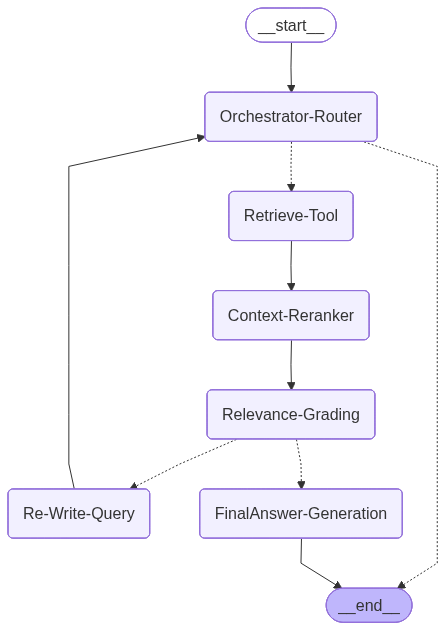

In [48]:
memory=MemorySaver()
workflow = StateGraph(RAGState)

# Add Functional Ingestion Processing Nodes
workflow.add_node("Orchestrator-Router", generate_query_or_respond)
workflow.add_node("Retrieve-Tool", ToolNode([retriever_tool]))
workflow.add_node("Context-Reranker", reranking_context)
workflow.add_node("Relevance-Grading", grading_the_documents)
workflow.add_node("Re-Write-Query", query_rewrite)
workflow.add_node("FinalAnswer-Generation", generate_response)

# Set Graph Ingestion EntryPoint Structure
workflow.add_edge(START, "Orchestrator-Router")

# Append Dynamic Flow Conditions Strategy
workflow.add_conditional_edges(
    "Orchestrator-Router",
    router_functions,
    {
        "Retrieve-Tool": "Retrieve-Tool",
        END: END
    }
)

# Connect Synchronous Data Flow Paths
workflow.add_edge("Retrieve-Tool", "Context-Reranker")
workflow.add_edge("Context-Reranker", "Relevance-Grading")

workflow.add_conditional_edges(
    "Relevance-Grading",
    route_after_grading,
    {
        "FinalAnswer-Generation": "FinalAnswer-Generation",
        "Re-Write-Query": "Re-Write-Query"
    }
)

# Close Query Translation Loops Safely
workflow.add_edge("Re-Write-Query", "Orchestrator-Router")
workflow.add_edge("FinalAnswer-Generation", END)

# Compile Pipeline with Memory Saver Checkpointer
app = workflow.compile(checkpointer=MemorySaver())
print("🎉 Graph compiled successfully without payload serialization bottlenecks!")
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"An Error Occured {e}")

In [29]:
config = {"configurable": {"thread_id": "development-test-run"}}
initial_state = {
    "user_query":"How does the book distinguish between an 'autonomous system' and an 'agentic AI' in terms of decision-making autonomy and adaptability?",
    "current_query": "",
    "messages": [],
    "rewrite_count": 0,
}

# Run execution flow cleanly
result = app.invoke(initial_state, config=config)
print("\nFinal Answer:\n", result.get("generation_response", "No response generated."))

[COHERE] Reranking 10 chunks for query: "How does the book distinguish between an 'autonomous system' and an 'agentic AI' in terms of decision-making autonomy and adaptability?"
[COHERE] Top rerank scores: [0.7805, 0.7369, 0.7169]
[GRADER] Relevance score: relevant
[ROUTER] Score='relevant' | Rewrites=0/2

=== GENERATING FINAL RESPONSE ===

Final Answer:
 The book contrasts the two types in the comparison table:

| Aspect | Autonomous Systems | Agentic AI |
|--------|-------------------|------------|
| **Decision‑making autonomy** | *Moderate* – they can operate independently in familiar domains but still rely on pre‑defined rules and limited self‑re‑prioritisation. | *High* – they can set their own sub‑goals, re‑prioritise tasks, and modify strategies on the fly in response to changes in the environment. |
| **Adaptability** | *Moderate* – they adapt within predefined operational parameters but do not dynamically learn new goals or contexts without external re‑programming. | *High* – 

In [49]:
eval_dataset = []

def add_to_eval(workflow_output: dict, ground_truth: str):
    """
    Add the responses of the RAG system for the evaluation using RAGAS Metrics
    """
    query = workflow_output.get("current_query") or workflow_output.get("user_query")
    response = workflow_output.get("generation_response", "")
    rerank_docs = workflow_output.get("rerank_context", [])
    
    # Safely extract text strings
    context_list = [doc.page_content for doc in rerank_docs if hasattr(doc, 'page_content')]
    
    # Anti-crash guardrail: If retriever failed to fetch anything, add a placeholder string
    # so RAGAS metrics don't face an empty array list-index exception.
    if not context_list:
        context_list = ["No relevant context found by retriever."]
        
    # Standardizing keys to match exactly what RAGAS dataset schema expects
    sample = {
        "user_input": query,
        "response": response,
        "retrieved_contexts": context_list, 
        "reference": ground_truth
    }
    
    eval_dataset.append(sample)
    print(f"✅ Data Captured for the Query: '{query}'")

In [50]:
test_cases = [

    # --- CONCEPTUAL DISTINCTIONS & DEFINITIONS ---
    {
        "q": "How does the book distinguish between an 'autonomous system' and an 'agentic AI' in terms of decision-making autonomy and adaptability?",
        "gt": "According to Table 1.1, autonomous systems have moderate adaptability within predefined operational parameters and moderate decision-making autonomy (capable of operating independently in familiar domains), whereas agentic AI has high adaptability that dynamically learns and adapts to new goals and environments without external reprogramming, and high decision-making autonomy where it can independently set sub-goals, reprioritize tasks, and modify strategies in response to environmental changes. Self-reflection is also absent in autonomous systems but fully present in agentic AI."
    },
    {
        "q": "What are the four key agentic properties/attributes defined in the book, and what does each mean?",
        "gt": "The book (Table 1.2) defines four agentic properties: (1) Autonomy – the ability to act without external control or instruction; (2) Intentionality – goal-oriented behaviour that reflects internal states or preferences; (3) Adaptivity – continuous learning and adjustment in response to feedback or environment; and (4) Persistence – sustained action over time directed toward objectives."
    },
    {
        "q": "How does the book define the formal structure of a classical planning problem, and what are the components of the tuple P?",
        "gt": "A classical planning problem is defined as a tuple P = ⟨S, A, T, s0, G⟩ where S is the set of all possible world states, A is the set of available actions, T is the transition function T: S × A → S, s0 is the initial state, and G is the set of goal states defined via logical predicates. Each action a is further defined as a = ⟨pre(a), eff(a)⟩, where pre(a) are preconditions and eff(a) are the effects (state transformation). A solution is a sequence of actions π = ⟨a1, a2, …, an⟩ such that applying them from s0 reaches a state in G."
    },

    # --- TECHNICAL DEPTH ---
    {
        "q": "What is the Markov Decision Process (MDP) formulation used for reinforcement learning in the book, and which agentic features does RL specifically enable?",
        "gt": "RL problems are modeled as MDPs defined by the tuple ⟨S, A, T, R, γ⟩ where S is the set of states, A is the set of actions, T(s'|s,a) represents transition probabilities, R(s,a) is the reward function, and γ is the discount factor for future rewards. The agent learns a policy π(a|s) that maximizes the expected cumulative reward E[Σ γᵗ R(st, at)]. The agentic features enabled by RL include: Autonomy (agents operate without explicit programming), Exploration (agents actively explore unknown parts of their environment), and Delayed gratification (RL optimizes long-term outcomes, not just immediate results)."
    },
    {
        "q": "What are the three key limitations of standard reinforcement learning identified in the book, and which two paradigms are proposed to address them?",
        "gt": "Standard RL suffers from three limitations: sample inefficiency (requiring millions of interactions), lack of transferability across tasks, and poor adaptation in non-stationary environments. These challenges motivate meta-learning and continual learning. Meta-learning (learning to learn) allows agents to generalize quickly to new tasks from limited experience, while continual learning preserves and updates knowledge over time without catastrophic forgetting."
    },
    {
        "q": "How does the book contrast Classical Planning with Hierarchical Task Networks (HTNs) across the dimensions of plan structure, reusability, and human interpretability?",
        "gt": "According to Table 4.1, Classical Planning uses flat sequences as its plan structure while HTN Planning uses a hierarchical (nested) structure. Reusability is limited in classical planning but high in HTNs due to reusable methods. Human interpretability is low in classical planning but high in HTNs. Scalability is moderate for classical planning but higher in HTNs because of decomposition. The fundamental difference is that classical planning is state-centric while HTNs are task-centric."
    },
    {
        "q": "What are the three types of meta-learning approaches described in the book, and what is the core idea behind gradient-based meta-learning (MAML)?",
        "gt": "The three meta-learning approaches are: (1) Gradient-Based Meta-Learning (MAML) – learns a shared initialization from which gradient descent quickly adapts to new tasks; examples include Reptile and FOMAML; (2) Metric-Based Meta-Learning – learns distance functions in embedding space; examples include Matching Networks and Prototypical Networks; (3) Memory-Based Meta-Learning – uses external memory to retrieve prior task experiences. The core idea of MAML is to find a parameter initialization that can be fine-tuned with very few gradient steps to perform well on a new task."
    },

    # --- ARCHITECTURES ---
    {
        "q": "Describe the BDI agent's perception-to-action cycle as outlined in the book, and name two real-world BDI frameworks mentioned.",
        "gt": "A BDI agent continuously cycles through four stages: Perception (updating beliefs based on new observations), Deliberation (evaluating which desires to pursue based on current beliefs), Intention Formation (committing to specific goals and plans), and Execution (acting in the environment while monitoring outcomes and revising intentions if needed). Two prominent BDI frameworks mentioned are PRS (Procedural Reasoning System), an early BDI system used in autonomous agents, and Jason, a Java-based implementation widely used in multi-agent simulations."
    },
    {
        "q": "How does the book compare SOAR, ACT-R, and CLARION cognitive architectures in terms of their strengths and limitations?",
        "gt": "According to Table 9.1: SOAR's strength is structured problem-solving and hierarchical goals, but its limitation is that it is symbolic and needs task-specific rules. ACT-R's strength is human-like memory validated against psychological experiments, but its limitation is limited scalability. CLARION's strength is modeling both implicit and explicit cognitive processes, but its limitation is less mature tooling. SOAR was developed at Carnegie Mellon and uses production rules with chunking, while ACT-R models cognition as interacting modules (declarative memory, procedural memory, perception, motor control) and has been extensively validated against psychological experiments."
    },
    {
        "q": "What are the four core agentic AI design patterns described in the book, and what distinguishes the 'Planning' pattern from the 'Reflection' pattern?",
        "gt": "The four core agentic AI design patterns are: (1) Reflection – the LLM reviews its own work to identify shortcomings and refine output, optionally using validation tools or a multi-agent critique setup; (2) Tool Use – equipping the LLM with external tools like web search, code execution, or data processing to act beyond text generation; (3) Planning – the LLM autonomously devises and executes a multi-step plan to reach a goal, dynamically choosing steps for complex non-linear tasks; (4) Multi-Agent Collaboration – multiple AI agents divide tasks, exchange ideas, and iterate toward better solutions. Planning differs from Reflection in that Planning is forward-looking and goal-driven (devising steps toward a target), whereas Reflection is backward-looking (evaluating and correcting work already produced). Planning is also described as less predictable than Reflection."
    },
    {
        "q": "What are the five agentic workflows that emerge when LLM calls are enhanced with retrieval, memory, and tool integration? Briefly describe each.",
        "gt": "The five agentic workflows are: (1) Prompt Chaining – a task is divided into sequential steps with each LLM call building on the previous, using programmatic checks for correctness; (2) Routing – inputs are classified and directed to specialized follow-up processes for optimal handling of different categories; (3) Parallelization – multiple LLMs work simultaneously for speed or diverse perspectives, either via Sectioning (splitting into independent subtasks) or Voting (running the same task multiple times); (4) Orchestrator–Workers – a central orchestrator LLM decomposes a complex task into adaptive subtasks assigned to worker LLMs, whose results are then synthesized; (5) Evaluator–Optimizer – one LLM generates output while another evaluates it against criteria and provides iterative feedback until quality is achieved."
    },

    # --- APPLICATIONS & REAL WORLD ---
    {
        "q": "How does the book describe the role of RAG (Retrieval-Augmented Generation) in agentic AI, and what are the two key steps it combines?",
        "gt": "RAG is described as a powerful technique that combines retrieval of relevant information with generation of natural language responses. Instead of relying solely on the AI model's internal (potentially outdated or incomplete) knowledge, RAG dynamically pulls up-to-date context from external sources such as document databases, APIs, or knowledge bases before producing an answer. In agentic AI, RAG is crucial for enabling agents to make factually grounded, context-aware decisions, work with current information, handle niche queries, and avoid hallucinations. Examples include a customer support agent retrieving troubleshooting guides, a clinical assistant querying a medical knowledge base, and an AI paralegal retrieving case law."
    },
    {
        "q": "What are the three safety mechanisms for autonomous vehicles described in the book, and what ethical dilemma is raised regarding their decision-making?",
        "gt": "The three AV safety mechanisms are: (1) Redundant Decision Layers – multiple models verifying or vetoing risky decisions; (2) Continuous Simulation Testing – virtual environments that stress-test rare but high-impact scenarios; (3) Fail-Safe Protocols – graceful handover to human drivers or safe-stop procedures when system confidence drops. The ethical dilemma raised is the 'trolley problem' analog: in unavoidable collision scenarios, how should the vehicle prioritize lives? The book also raises questions of transparency (how decisions are explained after accidents) and accountability (whether responsibility lies with the manufacturer, the AI system, or the operator)."
    },
    {
        "q": "What is the difference between Human-in-the-Loop (HITL) and Human-on-the-Loop (HOTL) oversight models in the context of safe agentic AI?",
        "gt": "Human-in-the-Loop (HITL) means that humans approve or modify AI decisions before they are executed—the human is a required step in the decision pipeline. Human-on-the-Loop (HOTL) means the AI acts autonomously but is continuously monitored, with humans retaining the ability to intervene if needed. The key difference is timing and control: HITL is pre-action approval, while HOTL is post-initiation monitoring with override capability."
    },

    # --- SOCIETAL & ETHICAL ---
    {
        "q": "What are the three major legal challenges that agentic AI poses, as described in Chapter 16, and what novel concept have some scholars proposed regarding AI legal responsibility?",
        "gt": "The three legal challenges are: (1) Liability and accountability – determining who is responsible when an autonomous agent causes harm (the designer, operator, or vendor), since traditional liability frameworks were built for tools, not independent actors; (2) Regulatory compliance and auditing – embedding compliance mechanisms into agent behaviour in highly regulated industries, requiring explainability, transparency logs, and algorithmic impact assessments; (3) Intellectual property and creative works – current IP law struggles to determine authorship when the creator is not human, as agentic AI can autonomously generate designs and inventions. Some scholars have proposed the concept of 'electronic personhood' in certain contexts, allowing AI to hold legal responsibility under a regulatory framework, though critics argue this would blur accountability."
    },
    {
        "q": "According to the book, when should engineers prefer deterministic workflows over agentic systems, and what is the 'agentless' approach?",
        "gt": "Deterministic workflows should be preferred when tasks are well-defined and predictable with a fixed number of steps, as they offer greater consistency, control, lower cost, and predictable results. Agentic systems trade speed and cost-efficiency for more advanced task performance and are better suited for open-ended, dynamic, multi-step, high-autonomy tasks where the exact number of steps cannot be predicted. The 'agentless' approach (exemplified by OpenAI's framework) focuses directly on solving the problem with minimal orchestration—such as enhancing standard LLM calls with retrieval and in-context examples—to avoid unnecessary complexity and the pitfalls of full agent-based systems."
    },

    # --- FUTURE DIRECTIONS & AGI ---
    {
        "q": "What are the four pathways to AGI outlined in the book, and what is the core advantage and key challenge of the 'Multi-Agent Emergence' pathway?",
        "gt": "The four AGI pathways from Table 17.1 are: (1) Modular Integration – specialization with unified coordination; challenge is knowledge transfer and goal conflicts; (2) Scaled Cognitive Architectures – rich reasoning and memory integration; challenge is complexity of scaling and adaptation; (3) Embodied Grounding – common-sense reasoning from interaction; challenge is physical safety and cost constraints; (4) Multi-Agent Emergence – distributed intelligence and robustness; challenge is coordination overhead and emergent risks. The core advantage of Multi-Agent Emergence is that AGI is not a single monolithic mind but a network of specialized agentic AIs collaborating dynamically, akin to distributed human organizations, producing collective intelligence that individual agents could not achieve alone."
    },
    {
        "q": "What are the four levels of machine self-awareness described in the book on the path toward AGI, from lowest to highest?",
        "gt": "The four levels of machine self-awareness, from lowest to highest, are: (1) Perceptual Self-Awareness – awareness of one's own sensory and actuation capabilities; (2) Operational Self-Awareness – awareness of one's computational resources and constraints; (3) Reflective Self-Awareness – awareness of one's reasoning strategies and decision biases; (4) Meta-Cognitive Self-Awareness – awareness of the process of self-awareness itself, i.e., recursive introspection. Reflective agency builds on these levels by actively using self-models in decision-making, such as choosing to explore uncertain domains due to recognized knowledge gaps or rewriting decision-making heuristics to improve long-term goal alignment."
    },
    {
        "q": "What are the three foundational design principles for safe agentic AI discussed in Chapter 18, and which specific techniques are mentioned for implementing 'value learning'?",
        "gt": "The three foundational design principles are: (1) Interpretability – making the agent's reasoning transparent to humans, using methods such as symbolic reason tracing, feature attribution maps (SHAP, LIME), counterfactual explanations, and narrative justification; (2) Value Learning and Corrigibility – ensuring the agent's goals remain aligned with human intentions. Value learning techniques include Inverse Reinforcement Learning (IRL, inferring values from observed human behaviour), Cooperative Inverse Reinforcement Learning (CIRL, where the agent collaborates with humans to discover shared values), and Preference Modelling (eliciting preferences through queries and feedback loops); Corrigibility ensures the agent remains receptive to correction and shutdown. (3) Moral Trade-Off Negotiation – enabling agents to resolve ethical dilemmas in real time using multi-objective optimisation."
    },
    {
        "q": "According to the book's historical timeline, what was the significance of the DARPA Autonomous Land Vehicle (ALV) program, and how did it relate to core agentic AI properties?",
        "gt": "The DARPA ALV program (1980s–1990s) was one of the earliest large-scale attempts to build a vehicle capable of navigating real-world terrain without constant human control. Equipped with early computer vision systems, LiDAR, and sensor fusion techniques, the ALV demonstrated that AI could integrate perception, planning, and control in a continuous loop—an early form of situated autonomy. Its significance for agentic AI is that it showed perception-action integration in a dynamic environment, even though the system was limited in adaptability. It laid the groundwork for modern autonomous systems that must reason about changing environments, directly foreshadowing the core agentic properties of situatedness and goal-directed behaviour."
    },

]

In [51]:
print("\n⚡ Triggering LangGraph Workflow over all 15 Test Cases...")

for index, case in enumerate(test_cases, 1):
    print(f"\n[Run {index}/15] Query: {case['q']}")
    config = {"configurable": {"thread_id": f"ragas-eval-run-{index}"}}
    
    # Matching your exact notebook initial state format
    initial_state = {
        "user_query": case["q"],
        "current_query": "",
        "messages": [],
        "rewrite_count": 0
    }
    
    try:
        # Invoking your LangGraph 'app' workflow with isolated session configs
        execution_output = app.invoke(initial_state, config=config)
        add_to_eval(execution_output, case["gt"])
    except Exception as error:
        print(f"❌ Execution failed for Test Case {index}: {error}")


⚡ Triggering LangGraph Workflow over all 15 Test Cases...

[Run 1/15] Query: How does the book distinguish between an 'autonomous system' and an 'agentic AI' in terms of decision-making autonomy and adaptability?
[COHERE] Reranking 10 chunks for query: "How does the book distinguish between an 'autonomous system' and an 'agentic AI' in terms of decision-making autonomy and adaptability?"
[COHERE] Top rerank scores: [0.7807, 0.7369, 0.7169, 0.6763, 0.6722, 0.6591]
[GRADER] Relevance score: relevant
[ROUTER] Score='relevant' | Rewrites=0/2

=== GENERATING FINAL RESPONSE ===
✅ Data Captured for the Query: 'How does the book distinguish between an 'autonomous system' and an 'agentic AI' in terms of decision-making autonomy and adaptability?'

[Run 2/15] Query: What are the four key agentic properties/attributes defined in the book, and what does each mean?
[COHERE] Reranking 10 chunks for query: 'What are the four key agentic properties/attributes defined in the book, and what does each m

In [52]:
# =====================================================================
# LATEST REVISED RUN WITH LOCAL EMBEDDING MODEL COUPLED
# =====================================================================
from ragas import EvaluationDataset
from ragas import evaluate
from ragas.metrics import _Faithfulness, _ResponseRelevancy, _ContextPrecision, _ContextRecall

# Reset dataset format according to what we corrected
evaluation_dataset = EvaluationDataset.from_list(eval_dataset)

# Re-initializing verified metric instances
faithfulness_metric = _Faithfulness()
answer_relevance_metric = _ResponseRelevancy()
context_precision_metric = _ContextPrecision()
context_recall_metric = _ContextRecall()

sahi_metrics_objects = [
    faithfulness_metric, 
    answer_relevance_metric, 
    context_precision_metric, 
    context_recall_metric
]

print("⚖️ Triggering RAGAS Evaluation Framework (Using OpenRouter LLM + Local Embeddings)...")

try:
    # Explicitly wrapping both LLM and your local embedding model
    evaluation_results = evaluate(
        dataset=evaluation_dataset,
        metrics=sahi_metrics_objects,
        llm=llm_2,                  # Aapka OpenRouter judge model
        embeddings=embedding_model   # <--- Aapka local HuggingFace embedding instance
    )
    
    print("\n🎉 Badhai ho! Evaluation Complete! Here is your 15 Test Cases Report:")
    df_report = evaluation_results.to_pandas()
    display(df_report)

except Exception as error:
    print(f"\n🔴 Evaluation block failed: {error}")
    print("If it says 'bge_embeddings' is not defined, please check what variable name you used for HuggingFace embeddings in the top cells.")


⚖️ Triggering RAGAS Evaluation Framework (Using OpenRouter LLM + Local Embeddings)...


Evaluating:   0%|          | 0/80 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 g


🎉 Badhai ho! Evaluation Complete! Here is your 15 Test Cases Report:


,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_precision,context_recall
0,How does the book distinguish between an 'auto...,[THE AGENTIC AI HANDBOOK \n \nKaushik Bar \n \...,**Decision‑making autonomy** \n* **Autonomous...,"According to Table 1.1, autonomous systems hav...",1.000000,0.823465,0.833333,1.000000
1,What are the four key agentic properties/attri...,[THE AGENTIC AI HANDBOOK \n \nKaushik Bar \n \...,**Four key agentic properties/attributes**\n\n...,The book (Table 1.2) defines four agentic prop...,1.000000,0.930650,1.000000,1.000000
2,How does the book define the formal structure ...,"[CONCEPTS, DESIGN PATTERNS, AND FUTURE DIRECTI...",The book defines a classical planning problem ...,A classical planning problem is defined as a t...,1.000000,0.761377,1.000000,1.000000
3,What is the Markov Decision Process (MDP) form...,[THE AGENTIC AI HANDBOOK \n \nKaushik Bar \n \...,The book defines the reinforcement‑learning pr...,RL problems are modeled as MDPs defined by the...,1.000000,0.725146,1.000000,0.666667
4,What are the three key limitations of standard...,[THE AGENTIC AI HANDBOOK \n \nKaushik Bar \n \...,The book identifies three key limitations of s...,Standard RL suffers from three limitations: sa...,1.000000,0.952538,1.000000,1.000000
5,How does the book contrast Classical Planning ...,[THE AGENTIC AI HANDBOOK \n \nKaushik Bar \n \...,The book highlights three key differences betw...,"According to Table 4.1, Classical Planning use...",0.857143,0.885872,1.000000,1.000000
6,What are the three types of meta-learning appr...,"[CONCEPTS, DESIGN PATTERNS, AND FUTURE DIRECTI...",The book lists three meta‑learning approaches:...,The three meta-learning approaches are: (1) Gr...,1.000000,0.949801,0.500000,1.000000
7,Describe the BDI agent's perception-to-action ...,"[CONCEPTS, DESIGN PATTERNS, AND FUTURE DIRECTI...",The book describes a BDI agent’s continuous **...,A BDI agent continuously cycles through four s...,1.000000,0.874662,0.000000,1.000000
8,comparison of strengths and limitations of SOA...,"[CONCEPTS, DESIGN PATTERNS, AND FUTURE DIRECTI...",**SOAR** \n- **Strengths:** Structured proble...,According to Table 9.1: SOAR's strength is str...,1.000000,0.953982,1.000000,1.000000
9,four core agentic artificial intelligence desi...,[while another evaluates it against defined cr...,This information is not available in my docume...,The four core agentic AI design patterns are: ...,0.000000,0.000000,0.000000,0.166667


In [53]:
output_filename = "chunk=1500,overlap=600,top_k=6.xlsx"
df_report.to_excel(output_filename, index=False)

print(f"🎉 Evaluation report successfully saved to {output_filename}!")

🎉 Evaluation report successfully saved to chunk=1500,overlap=600,top_k=6.xlsx!
